# Music Recommendor Algorithm
### Collaborators: Aisha Mardini, Lilly Peters, Shinung Li

## First dataset:
- https://www.kaggle.com/datasets/maharshipandya/-spotify-tracks-dataset
- Used for content based filtering

\
___Elements___

- **track_id:** The Spotify ID for the song
- **artists:** The artists' names. If there is more than one artist, they are separated by a ;
- **album_name:** The album name
- **track_name:** Name of the track
- **popularity:** The popularity is calculated by Spotify's algorithm from [0,100]. Based on the total number of plays the track has had and how recent those plays are. 
- **duration_ms:** The song length in milliseconds
- **explicit:** Whether or not the song has explicit lyrics (true = yes; false = no OR unknown)
- **danceability:** How suitable a track is for dancing from [0,1] based on a combination of elements including tempo, rhythm stability, beat strength, and overall regularity. 
- **energy:** Represents a perceptual measure of intensity and activity from [0,1]. Typically, energetic tracks feel fast, loud, and noisy. 
- **key:** The key the track is in mapped using standard Pitch Class notation. E.g. 0 = C, 1 = C♯/D♭, 2 = D, and so on. If no key was detected, the value is -1
- **loudness:** How loud the track is in decibels
- **mode:** Mode indicates the modality (major or minor) of a trackMajor is represented by 1 and minor is 0
- **speechiness:** Speechiness detects the presence of spoken words in a track from [0,1]
- **acousticness:** Whether the track is acoustic from [0,1]. 1.0 represents high confidence the track is acoustic
- **instrumentalness:** Predicts whether a track contains no vocals from [0,1]
- **liveness:** Detects the presence of an audience in the recording from [0,1]
- **valence:** Musical positiveness conveyed by a track from [0,1]. Tracks with high valence sound more positive (e.g. happy, cheerful, euphoric), while tracks with low valence sound more negative (e.g. sad, depressed, angry)
- **tempo:** Estimated tempo of a track in beats per minute (BPM). 
- **time_signature:** An estimated time signature. The time signature (meter) is a notational convention to specify how many beats are in each bar (or measure). The time signature ranges from 3 to 7 indicating time signatures of 3/4, to 7/4.
- **track_genre:** The genre of the song

## Step 1:
- Upload the data
- Data cleaning and preprocessing

In [190]:
# import libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.sparse import csr_matrix
from sklearn.preprocessing import LabelEncoder
from sklearn.decomposition import NMF
import random

# Loading in Spotify datasets
df_read = pd.read_csv('/Users/aishamardini/Downloads/PIC16B/dataset.csv') # MUST DOWNLOAD LOCALLY AND CHANGE PATH
df_read.head()

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.68,0.46,...,-6.75,0,0.14,0.03,0.00,0.36,0.71,87.92,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.42,0.17,...,-17.23,1,0.08,0.92,0.00,0.10,0.27,77.49,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.44,0.36,...,-9.73,1,0.06,0.21,0.00,0.12,0.12,76.33,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.27,0.06,...,-18.52,1,0.04,0.91,0.00,0.13,0.14,181.74,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.62,0.44,...,-9.68,1,0.05,0.47,0.00,0.08,0.17,119.95,4,acoustic


In [191]:
# checking if there are NaN values in track id, artists, albums
df_read[df_read["track_id"].isna()]

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre


In [192]:
df_read[df_read["artists"].isna()]

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
65900,65900,1kR4gIb7nGxHPI3D2ifs59,NaN,NaN,NaN,0,0,False,0.50,0.58,...,-9.46,0,0.06,0.69,0.00,0.07,0.73,138.39,4,k-pop


In [193]:
df_read[df_read["album_name"].isna()]

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
65900,65900,1kR4gIb7nGxHPI3D2ifs59,NaN,NaN,NaN,0,0,False,0.50,0.58,...,-9.46,0,0.06,0.69,0.00,0.07,0.73,138.39,4,k-pop


In [194]:
# drop nan values
df_read = df_read.dropna()

In [195]:
# check to see if any rows are duplicates and drop them
#print(df_read.drop_duplicates().any())
df_read = df_read.drop_duplicates()

In [196]:
# checking the types for columns
df_read.dtypes

Unnamed: 0            int64
track_id             object
artists              object
album_name           object
track_name           object
popularity            int64
duration_ms           int64
explicit               bool
danceability        float64
energy              float64
key                   int64
loudness            float64
mode                  int64
speechiness         float64
acousticness        float64
instrumentalness    float64
liveness            float64
valence             float64
tempo               float64
time_signature        int64
track_genre          object
dtype: object

In [197]:
# drop the unnamed column
df = df_read.drop(columns=['Unnamed: 0'])

In [198]:
# check column names
df.columns

Index(['track_id', 'artists', 'album_name', 'track_name', 'popularity',
       'duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness',
       'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness',
       'valence', 'tempo', 'time_signature', 'track_genre'],
      dtype='object')

In [199]:
# check statistics
df.describe()

,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,113999.00,113999.00,113999.00,113999.00,113999.00,113999.00,113999.00,113999.00,113999.00,113999.00,113999.00,113999.00,113999.00,113999.00
mean,33.24,228031.15,0.57,0.64,5.31,-8.26,0.64,0.08,0.31,0.16,0.21,0.47,122.15,3.90
std,22.30,107296.06,0.17,0.25,3.56,5.03,0.48,0.11,0.33,0.31,0.19,0.26,29.98,0.43
min,0.00,8586.00,0.00,0.00,0.00,-49.53,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,17.00,174066.00,0.46,0.47,2.00,-10.01,0.00,0.04,0.02,0.00,0.10,0.26,99.22,4.00
50%,35.00,212906.00,0.58,0.69,5.00,-7.00,1.00,0.05,0.17,0.00,0.13,0.46,122.02,4.00
75%,50.00,261506.00,0.69,0.85,8.00,-5.00,1.00,0.08,0.60,0.05,0.27,0.68,140.07,4.00
max,100.00,5237295.00,0.98,1.00,11.00,4.53,1.00,0.96,1.00,1.00,1.00,0.99,243.37,5.00


In [200]:
# check to see if multiartists are separated by semicolon
df[df["artists"].str.contains(";")]["artists"].unique()[:20]

array(['Ingrid Michaelson;ZAYN', 'A Great Big World;Christina Aguilera',
       'Jason Mraz;Colbie Caillat', 'Chord Overstreet;Deepend',
       'Andrew Foy;Renee Foy', 'Boyce Avenue;Bea Miller',
       'Boyce Avenue;Jennel Garcia', 'Brandi Carlile;Sam Smith',
       'Brandi Carlile;Lucius', 'Eddie Vedder;Nusrat Fateh Ali Khan',
       'Boyce Avenue;Fifth Harmony', 'Gabrielle Aplin;JP Cooper',
       'Ray LaMontagne;Sierra Ferrell', 'Susie Suh;Robot Koch',
       'Tyler Ward;Lindsey Stirling;Kina Grannis', 'Eden Elf;Ren Avel',
       'Boyce Avenue;Rachel Grae', 'Zack Tabudlo;Yonnyboii',
       'Tyler Ward;Karis;Ray Lorraine', 'Agustín Amigó;Nylonwings'],
      dtype=object)

In [201]:
# how many loudness columns are 0
(df["loudness"] == 0).sum()

np.int64(0)

In [202]:
# how many instrumentalness columns are 0
(df["instrumentalness"] == 0).sum()

np.int64(38763)

In [203]:
# how many tempo columns are 0
(df["tempo"] == 0).sum()

np.int64(157)

In [204]:
# drop temp columns that are 0
df = df[df["tempo"] != 0]

In [205]:
# remove artist's duplicated songs
df = df.sort_values("popularity", ascending=False).drop_duplicates(subset=["track_name", "artists"], keep="first")

In [206]:
# check to see dropped
df.duplicated(subset=["track_name", "artists"]).sum()

np.int64(0)

In [207]:
# remove songs with popularity == 0
df = df[df["popularity"] > 0]

In [208]:
# check statistics again
df.describe()

,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,76444.00,76444.00,76444.00,76444.00,76444.00,76444.00,76444.00,76444.00,76444.00,76444.00,76444.00,76444.00,76444.00,76444.00
mean,37.44,231588.51,0.56,0.64,5.29,-8.47,0.63,0.09,0.32,0.18,0.22,0.47,122.64,3.91
std,17.85,115299.29,0.17,0.25,3.56,5.14,0.48,0.12,0.34,0.33,0.20,0.26,29.64,0.42
min,1.00,24266.00,0.05,0.00,0.00,-46.59,0.00,0.02,0.00,0.00,0.01,0.00,30.32,0.00
25%,23.00,174106.00,0.45,0.47,2.00,-10.30,0.00,0.04,0.01,0.00,0.10,0.25,99.95,4.00
50%,37.00,215774.50,0.58,0.68,5.00,-7.22,1.00,0.05,0.18,0.00,0.13,0.45,122.52,4.00
75%,50.00,267906.00,0.69,0.86,8.00,-5.13,1.00,0.09,0.61,0.14,0.28,0.68,140.82,4.00
max,100.00,5237295.00,0.98,1.00,11.00,4.53,1.00,0.96,1.00,1.00,1.00,0.99,243.37,5.00


## 2nd Dataset
\
Second Dataset:
- https://www.kaggle.com/competitions/kkbox-music-recommendation-challenge/data
- Download: train.csv, songs.csv, members.csv, and song_extra_info.csv
- Used for collaborative filtering

In [210]:
# print info of all datasets
datasets = [train, songs, members, song_extra]
d = ["train", "songs", "members", "song_extra_info"]

for i, ds in enumerate(datasets):
    print(d[i] + ".csv information:")
    print("Column names: ", ds.columns)
    print("Number of duplicates: ", ds.duplicated().sum())
    print("Number of null in columns: \n", ds.isnull().sum())
    print()

train.csv information:
Column names:  Index(['msno', 'song_id', 'source_system_tab', 'source_type', 'target'], dtype='object')
Number of duplicates:  0
Number of null in columns: 
 msno                     0
song_id                  0
source_system_tab    24849
source_type          21528
target                   0
dtype: int64

songs.csv information:
Column names:  Index(['song_id', 'song_length', 'genre_ids', 'artist_name', 'composer',
       'lyricist', 'language'],
      dtype='object')
Number of duplicates:  0
Number of null in columns: 
 song_id              0
song_length          0
genre_ids        94116
artist_name          0
composer       1071358
lyricist       1945306
language             1
dtype: int64

members.csv information:
Column names:  Index(['bd', 'msno', 'city'], dtype='object')
Number of duplicates:  0
Number of null in columns: 
 bd      0
msno    0
city    0
dtype: int64

song_extra_info.csv information:
Column names:  Index(['song_id', 'name', 'isrc'], dtype='ob

In [211]:
# load in all 2nd datasets; view columns
# DOWNLOAD ALL LOCALLY AND CHANGE PATHS
train = pd.read_csv('/Users/aishamardini/Downloads/PIC16B/train.csv')
songs = pd.read_csv('/Users/aishamardini/Downloads/PIC16B/songs.csv')
members = pd.read_csv('/Users/aishamardini/Downloads/PIC16B/members.csv')
song_extra = pd.read_csv('/Users/aishamardini/Downloads/PIC16B/song_extra_info.csv')

In [212]:
# select columns for main dataset
train = train[['msno', 'song_id', 'source_system_tab', 'source_type', 'target']]
print("Number of appreances: ", train['source_system_tab'].value_counts())
train = train[~train['source_system_tab'].isin(['notification', 'settings'])]

Number of appreances:  source_system_tab
my library      3684730
discover        2179252
search           623286
radio            476701
listen with      212266
explore          167949
notification       6185
settings           2200
Name: count, dtype: int64


In [213]:
# print data
train

,msno,song_id,source_system_tab,source_type,target
0,FGtllVqz18RPiwJj/edr2gV78zirAiY/9SmYvia+kCg=,BBzumQNXUHKdEBOB7mAJuzok+IJA1c2Ryg/yzTF6tik=,explore,online-playlist,1
1,Xumu+NIjS6QYVxDS4/t3SawvJ7viT9hPKXmf0RtLNx8=,bhp/MpSNoqoxOIB+/l8WPqu6jldth4DIpCm3ayXnJqM=,my library,local-playlist,1
2,Xumu+NIjS6QYVxDS4/t3SawvJ7viT9hPKXmf0RtLNx8=,JNWfrrC7zNN7BdMpsISKa4Mw+xVJYNnxXh3/Epw7QgY=,my library,local-playlist,1
3,Xumu+NIjS6QYVxDS4/t3SawvJ7viT9hPKXmf0RtLNx8=,2A87tzfnJTSWqD7gIZHisolhe4DMdzkbd6LzO1KHjNs=,my library,local-playlist,1
4,FGtllVqz18RPiwJj/edr2gV78zirAiY/9SmYvia+kCg=,3qm6XTZ6MOCU11x8FIVbAGH5l5uMkT3/ZalWG1oo2Gc=,explore,online-playlist,1
...,...,...,...,...,...
7377413,6xdFzPlrasIDD95mQWXVC3Bg4ptnGYtBl4ztVEZMddU=,VJTxizih/o28kXCbtPbIyWXScoXGvxyYtl6R+0YB5JM=,my library,local-playlist,1
7377414,ZxbVmt3Kh/XOH+h58c2Kdj6SjFZk+wnUO006IgWzMQE=,z1mqaU9YOX7T/PFDvUoWozdFq7rC3KwaQP7nFVprjMI=,search,song,0
7377415,ZxbVmt3Kh/XOH+h58c2Kdj6SjFZk+wnUO006IgWzMQE=,750RprmFfLV0bymtDH88g24pLZGVi5VpBAI300P6UOA=,search,song,1
7377416,0aH4Hd3ziPSRHClRX8rkeOEaAG5EPPkW1mKGCdXEok0=,G8wgqObgeAMER/rVCIlgcNeQ8mm0CzF/GsxiMK8TTnA=,discover,online-playlist,1


In [214]:
# 2nd dataset drop NAN
members = members[['bd', 'msno', 'city']]
members.dropna()

,bd,msno,city
0,0,XQxgAYj3klVKjR3oxPPXYYFp4soD4TuBghkhMTD4oTw=,1
1,0,UizsfmJb9mV54qE9hCYyU07Va97c0lCRLEQX3ae+ztM=,1
2,0,D8nEhsIOBSoE6VthTaqDX8U6lqjJ7dLdr72mOyLya2A=,1
3,0,mCuD+tZ1hERA/o5GPqk38e041J8ZsBaLcu7nGoIIvhI=,1
4,0,q4HRBfVSssAFS9iRfxWrohxuk9kCYMKjHOEagUMV6rQ=,1
...,...,...,...
34398,0,Wwd/cudKVuLJ3txRVxlg2Zaeliu+LRUfiBmfrnxhRCY=,1
34399,18,g3JGnJX6Hg50lFbrNWfsHwCUmApIkiv2M8sXOaeXoIQ=,4
34400,0,IMaPMJuyN+ip9Vqi+z2XuXbFAP2kbHr+EvvCNkFfj+o=,1
34401,0,WAnCAJjUty9Stv8yKtV7ZC7PN+ilOy5FX3aIJgGPANM=,1


In [215]:
# FIRST MERGE: add a song name column by merging the 2 datasets based on song id

merged_song = pd.merge(songs, song_extra[['song_id', 'name']], on='song_id', how='left')
merged_song = merged_song.drop_duplicates()
merged_song.dropna()
# cut unneeded columns
merged_song = merged_song[['artist_name', 'name', 'song_id']]

In [216]:
print("1st Merged Dataset (Song Names and ID):")
merged_song

1st Merged Dataset (Song Names and ID):


,artist_name,name,song_id
0,張信哲 (Jeff Chang),焚情,CXoTN1eb7AI+DntdU1vbcwGRV4SCIDxZu+YD8JP8r4E=
1,BLACKPINK,PLAYING WITH FIRE,o0kFgae9QtnYgRkVPqLJwa05zIhRlUjfF7O1tDw0ZDU=
2,SUPER JUNIOR,SORRY| SORRY,DwVvVurfpuz+XPuFvucclVQEyPqcpUkHR0ne1RQzPs0=
3,S.H.E,愛我的資格,dKMBWoZyScdxSkihKG+Vf47nc18N9q4m58+b4e7dSSE=
4,貴族精選,Mary Had a Little Lamb,W3bqWd3T+VeHFzHAUfARgW9AvVRaF4N5Yzm4Mr6Eo/o=
...,...,...,...
2296315,Catherine Collard,Schumann: Papillons| Op. 2: II. Prestissimo,lg6rn7eV/ZNg0+P+x77kHUL7GDMfoL4eMtXxncseLNA=
2296316,紀文惠 (Justine Chi),怎麼啦,nXi1lrSJe+gLoTTNky7If0mNPrIyCQCLwagwR6XopGU=
2296317,Various Artists,Still Here,9KxSvIjbJyJzfEVWnkMbgR6dyn6d54ot0N5FKyKqii8=
2296318,Peter Paul & Mary,If I Had My Way,UO8Y2MR2sjOn2q/Tp8/lzZTGKmLEvwZ20oWanG4XnYc=


In [217]:
# check if theres any duplicates
print("How many duplicated songs in dataset: ", merged_song.duplicated().sum())

How many duplicated songs in dataset:  0


In [218]:
# SECOND merging 
colab_df = pd.merge(train, merged_song[['song_id', 'name', 'artist_name']], on='song_id', how='left')
colab_df

,msno,song_id,source_system_tab,source_type,target,name,artist_name
0,FGtllVqz18RPiwJj/edr2gV78zirAiY/9SmYvia+kCg=,BBzumQNXUHKdEBOB7mAJuzok+IJA1c2Ryg/yzTF6tik=,explore,online-playlist,1,Good Grief,Bastille
1,Xumu+NIjS6QYVxDS4/t3SawvJ7viT9hPKXmf0RtLNx8=,bhp/MpSNoqoxOIB+/l8WPqu6jldth4DIpCm3ayXnJqM=,my library,local-playlist,1,Lords of Cardboard,Various Artists
2,Xumu+NIjS6QYVxDS4/t3SawvJ7viT9hPKXmf0RtLNx8=,JNWfrrC7zNN7BdMpsISKa4Mw+xVJYNnxXh3/Epw7QgY=,my library,local-playlist,1,Hip Hop Is Dead(Album Version (Edited)),Nas
3,Xumu+NIjS6QYVxDS4/t3SawvJ7viT9hPKXmf0RtLNx8=,2A87tzfnJTSWqD7gIZHisolhe4DMdzkbd6LzO1KHjNs=,my library,local-playlist,1,Disco Africa,Soundway
4,FGtllVqz18RPiwJj/edr2gV78zirAiY/9SmYvia+kCg=,3qm6XTZ6MOCU11x8FIVbAGH5l5uMkT3/ZalWG1oo2Gc=,explore,online-playlist,1,Sleep Without You,Brett Young
...,...,...,...,...,...,...,...
7369028,6xdFzPlrasIDD95mQWXVC3Bg4ptnGYtBl4ztVEZMddU=,VJTxizih/o28kXCbtPbIyWXScoXGvxyYtl6R+0YB5JM=,my library,local-playlist,1,Still D.R.E.,Dr. Dre
7369029,ZxbVmt3Kh/XOH+h58c2Kdj6SjFZk+wnUO006IgWzMQE=,z1mqaU9YOX7T/PFDvUoWozdFq7rC3KwaQP7nFVprjMI=,search,song,0,Locked Away,R. City feat. Adam Levine
7369030,ZxbVmt3Kh/XOH+h58c2Kdj6SjFZk+wnUO006IgWzMQE=,750RprmFfLV0bymtDH88g24pLZGVi5VpBAI300P6UOA=,search,song,1,FLY OUT,兄弟本色G.U.T.S. (姚中仁、張震嶽、頑童MJ116)
7369031,0aH4Hd3ziPSRHClRX8rkeOEaAG5EPPkW1mKGCdXEok0=,G8wgqObgeAMER/rVCIlgcNeQ8mm0CzF/GsxiMK8TTnA=,discover,online-playlist,1,Wonderwall,Brad Mehldau Trio


In [219]:
# FINAL merged and clean dataset
collab = pd.merge(colab_df, members[['bd', 'msno', 'city']], on='msno', how='left')

# rename columns to be more explicit
collab = collab.rename(columns={'bd': 'age', 'msno':'user', 'target':'repeated'})

# source_system_tab sees where the song was found (either in the playlist, search, discover, explore, radio, or listened with someone)
collab = collab.dropna(subset=['source_system_tab'])

print("Unique outputs in source_system_tab ", collab['source_system_tab'].unique())


Unique outputs in source_system_tab  ['explore' 'my library' 'search' 'discover' 'radio' 'listen with']


In [220]:
# encode source system tab column 1-6
# strongest signal to weakest
collab['source_system_tab'] = collab['source_system_tab'].map(
    {
    'my library': 6, 
    'search': 5, 
    'discover': 4,      
    'explore': 3, 
    'radio': 2,
    'listen with': 1 
    })


In [221]:
# view distribution of values
collab['source_system_tab'].unique()
collab['source_system_tab'].value_counts()

source_system_tab
6    3684730
4    2179252
5     623286
2     476701
1     212266
3     167949
Name: count, dtype: int64

In [222]:
print("FINAL Merged Dataset:")
collab

FINAL Merged Dataset:


,user,song_id,source_system_tab,source_type,repeated,name,artist_name,age,city
0,FGtllVqz18RPiwJj/edr2gV78zirAiY/9SmYvia+kCg=,BBzumQNXUHKdEBOB7mAJuzok+IJA1c2Ryg/yzTF6tik=,3,online-playlist,1,Good Grief,Bastille,0,1
1,Xumu+NIjS6QYVxDS4/t3SawvJ7viT9hPKXmf0RtLNx8=,bhp/MpSNoqoxOIB+/l8WPqu6jldth4DIpCm3ayXnJqM=,6,local-playlist,1,Lords of Cardboard,Various Artists,24,13
2,Xumu+NIjS6QYVxDS4/t3SawvJ7viT9hPKXmf0RtLNx8=,JNWfrrC7zNN7BdMpsISKa4Mw+xVJYNnxXh3/Epw7QgY=,6,local-playlist,1,Hip Hop Is Dead(Album Version (Edited)),Nas,24,13
3,Xumu+NIjS6QYVxDS4/t3SawvJ7viT9hPKXmf0RtLNx8=,2A87tzfnJTSWqD7gIZHisolhe4DMdzkbd6LzO1KHjNs=,6,local-playlist,1,Disco Africa,Soundway,24,13
4,FGtllVqz18RPiwJj/edr2gV78zirAiY/9SmYvia+kCg=,3qm6XTZ6MOCU11x8FIVbAGH5l5uMkT3/ZalWG1oo2Gc=,3,online-playlist,1,Sleep Without You,Brett Young,0,1
...,...,...,...,...,...,...,...,...,...
7369028,6xdFzPlrasIDD95mQWXVC3Bg4ptnGYtBl4ztVEZMddU=,VJTxizih/o28kXCbtPbIyWXScoXGvxyYtl6R+0YB5JM=,6,local-playlist,1,Still D.R.E.,Dr. Dre,26,4
7369029,ZxbVmt3Kh/XOH+h58c2Kdj6SjFZk+wnUO006IgWzMQE=,z1mqaU9YOX7T/PFDvUoWozdFq7rC3KwaQP7nFVprjMI=,5,song,0,Locked Away,R. City feat. Adam Levine,0,1
7369030,ZxbVmt3Kh/XOH+h58c2Kdj6SjFZk+wnUO006IgWzMQE=,750RprmFfLV0bymtDH88g24pLZGVi5VpBAI300P6UOA=,5,song,1,FLY OUT,兄弟本色G.U.T.S. (姚中仁、張震嶽、頑童MJ116),0,1
7369031,0aH4Hd3ziPSRHClRX8rkeOEaAG5EPPkW1mKGCdXEok0=,G8wgqObgeAMER/rVCIlgcNeQ8mm0CzF/GsxiMK8TTnA=,4,online-playlist,1,Wonderwall,Brad Mehldau Trio,0,5


In [223]:
# column names for final dataset
collab.columns

Index(['user', 'song_id', 'source_system_tab', 'source_type', 'repeated',
       'name', 'artist_name', 'age', 'city'],
      dtype='object')

# EXTRA CLEANING

In [225]:
# cleaning data further

collab = collab[(collab['age'] > 0) & (collab['age'] < 100)] # remove all instances where age is 0 or impossible

collab.isnull().sum() # count number of NAs
collab = collab.dropna()   # drop Nas
collab.isnull().sum()    # check to make sure actually dropped


pd.set_option('display.float_format', '{:.2f}'.format)
collab.info()
collab.isnull().sum()
collab.describe()

<class 'pandas.core.frame.DataFrame'>
Index: 4405209 entries, 1 to 7369028
Data columns (total 9 columns):
 #   Column             Dtype 
---  ------             ----- 
 0   user               object
 1   song_id            object
 2   source_system_tab  int64 
 3   source_type        object
 4   repeated           int64 
 5   name               object
 6   artist_name        object
 7   age                int64 
 8   city               int64 
dtypes: int64(4), object(5)
memory usage: 336.1+ MB


,source_system_tab,repeated,age,city
count,4405209.00,4405209.00,4405209.00,4405209.00
mean,4.88,0.51,28.72,10.78
std,1.41,0.50,8.63,5.86
min,1.00,0.00,2.00,1.00
25%,4.00,0.00,23.00,5.00
50%,6.00,1.00,27.00,13.00
75%,6.00,1.00,33.00,14.00
max,6.00,1.00,95.00,22.00


In [299]:
# how many users show up less than 20 times
print(user_counts[user_counts < 20].count())

1361


In [227]:
# clean users
collab["user"].nunique()  # number of unique users
user_counts = collab["user"].value_counts()
# keep users who appear more than 20 times 
collab = collab[collab["user"].isin(user_counts[user_counts > 20].index)] 
collab["song_id"].nunique()

277788

DATA ANALYTICS

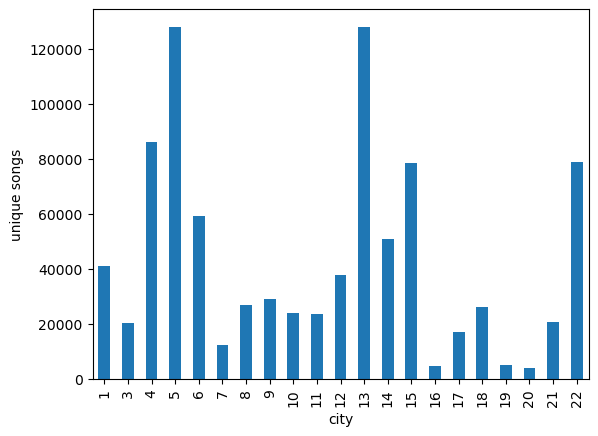

In [229]:
collab.groupby('city')['song_id'].value_counts()

city_songs = collab.groupby(['city', 'song_id'])['repeated'].sum().reset_index()
city_songs = city_songs.sort_values(['city', 'repeated'], ascending=[True, False])

# see top 5 songs per city
city_songs.groupby('city').head(5)

collab.groupby('city')['song_id'].nunique().plot(kind='bar')
plt.xlabel('city')
plt.ylabel('unique songs')
plt.savefig('city.png', dpi=300, bbox_inches='tight')
plt.show()

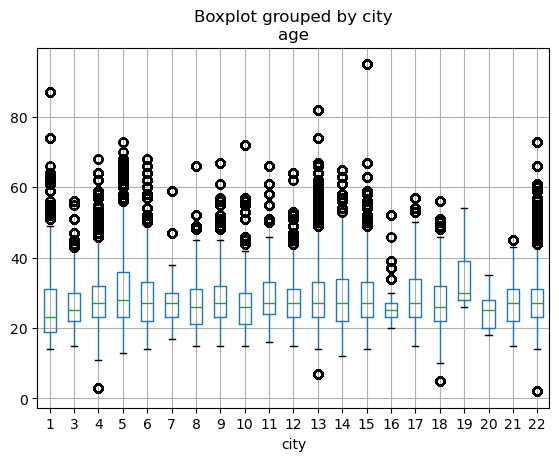

In [230]:
collab.boxplot(column='age', by='city')
plt.show()

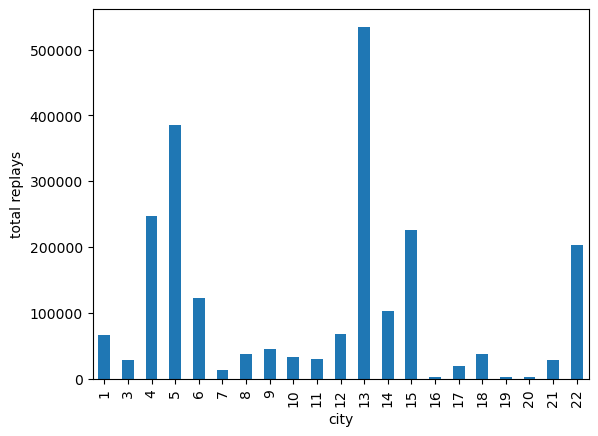

In [231]:
collab.groupby('city')['repeated'].sum().plot(kind='bar')
plt.ylabel('total replays')
plt.xlabel('city')
plt.show()

City 13 had the most replays and the most unique songs. City 5 had the second most unique songs, and city 15 and city 22 had a close number of unique songs (count). 

## Step 2:
- Data Visualization for content based filtering

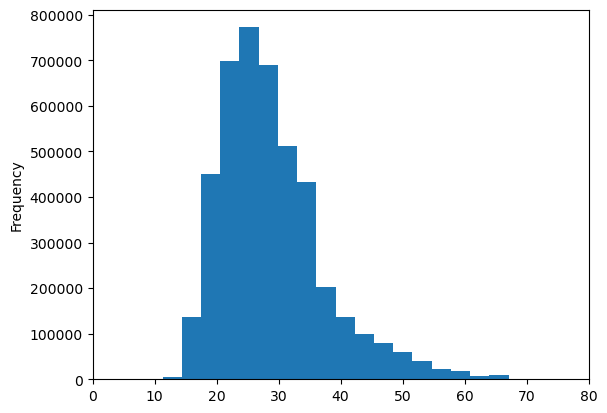

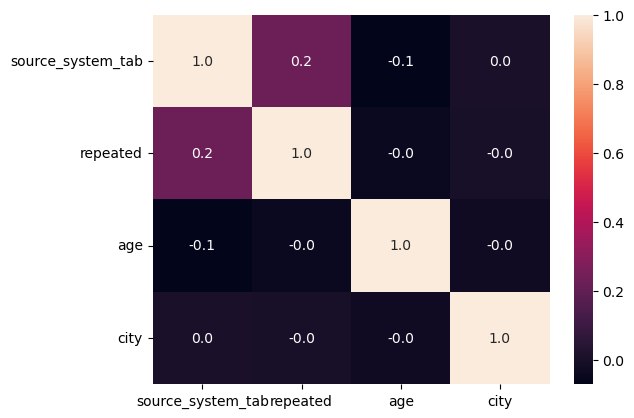

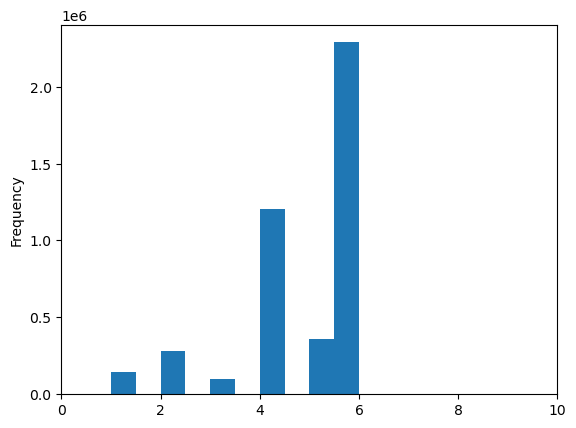

source_system_tab
6    2288328
4    1205724
5     361226
2     281531
1     147609
3      97791
Name: count, dtype: int64

In [234]:
import matplotlib.pyplot as plt
#age distribition
collab['age'].plot(kind='hist', bins=30) # visualize age distribution counts
plt.xlim(0, 80) # shorten the x axis so it's a clearer picture
plt.show()

# correlation heatmap
sns.heatmap(collab.corr(numeric_only=True), annot=True, fmt=".1f")
plt.show()

#frequency table for source system tabs
collab['source_system_tab'].plot(kind='hist', bins=10)
plt.xlim(0, 10)
plt.show()

collab['source_system_tab'].value_counts()

In [235]:
# check column names
df.columns

Index(['track_id', 'artists', 'album_name', 'track_name', 'popularity',
       'duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness',
       'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness',
       'valence', 'tempo', 'time_signature', 'track_genre'],
      dtype='object')

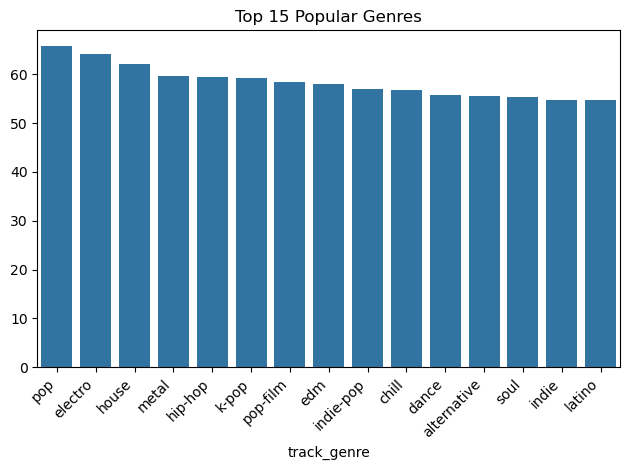

In [236]:
# bar plot of the first 15 most popular genres
plt.title("Top 15 Popular Genres")
genre_pop = df.groupby("track_genre")["popularity"].mean().sort_values(ascending=False).head(15)
sns.barplot(x=genre_pop.index, y=genre_pop.values)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

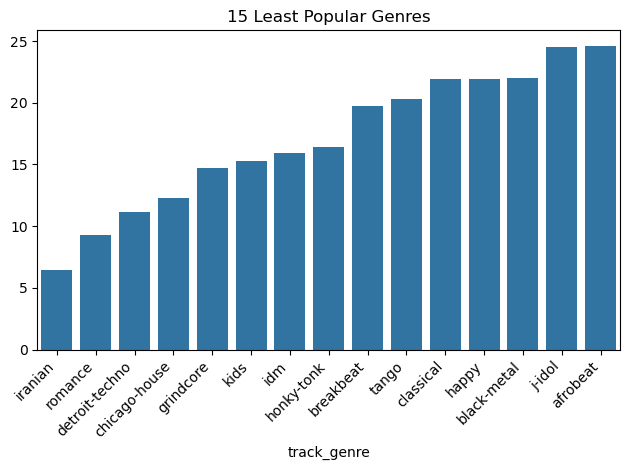

In [237]:
# plot for the 15 least popular genres
plt.title("15 Least Popular Genres")
genre_pop = df.groupby("track_genre")["popularity"].mean().sort_values(ascending=True).head(15)
sns.barplot(x=genre_pop.index, y=genre_pop.values)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

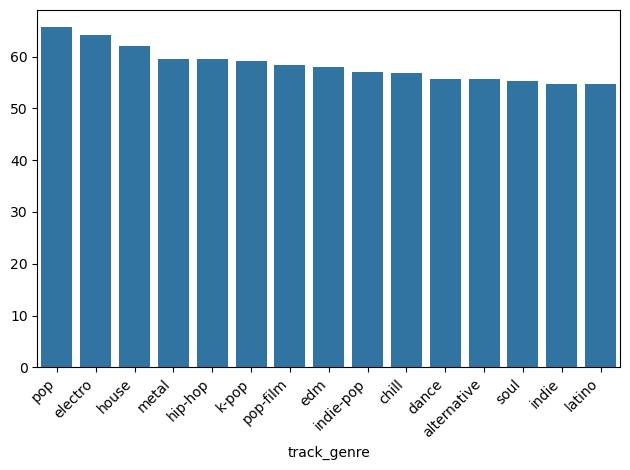

In [238]:
genre_pop = df.groupby("track_genre")["popularity"].mean().sort_values(ascending=False).head(15)
sns.barplot(x=genre_pop.index, y=genre_pop.values)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

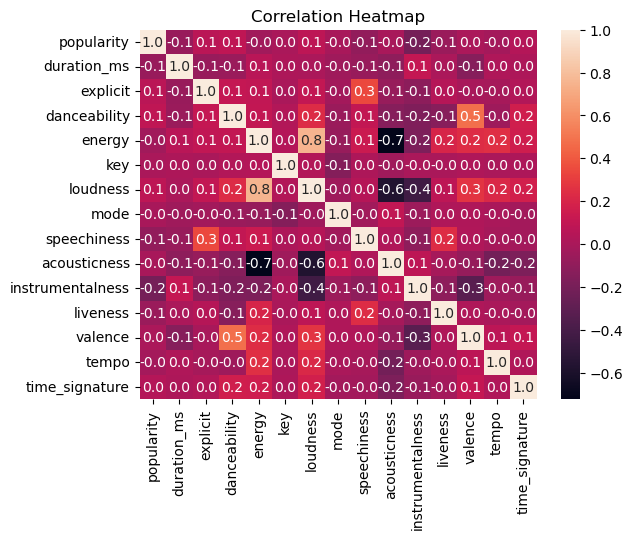

In [239]:
# heatmap plot correlating features
plt.title("Correlation Heatmap")
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt=".1f")
plt.show()

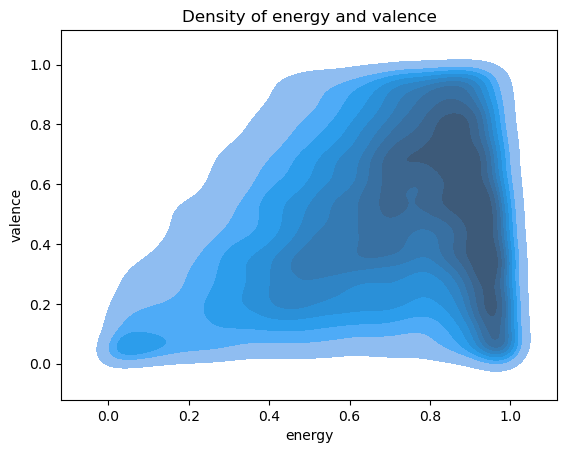

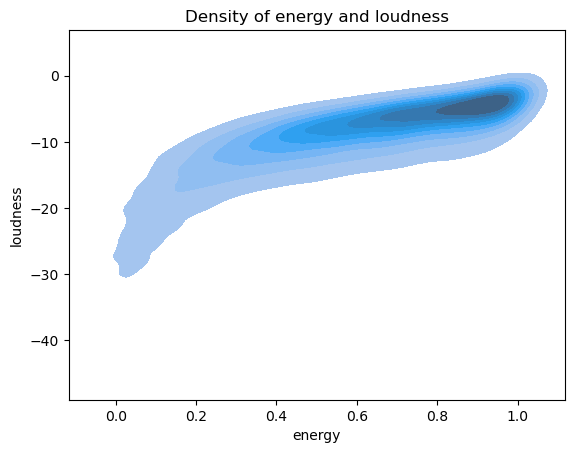

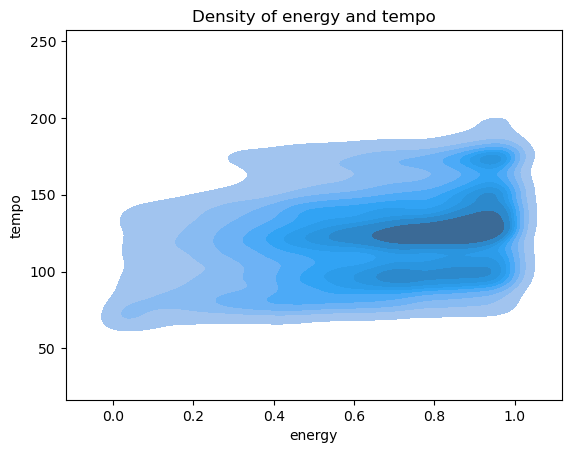

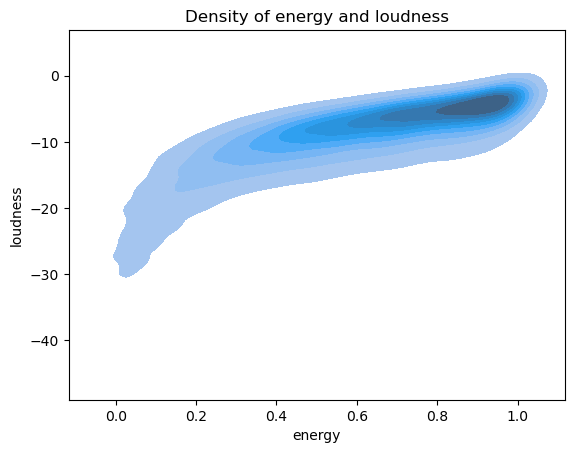

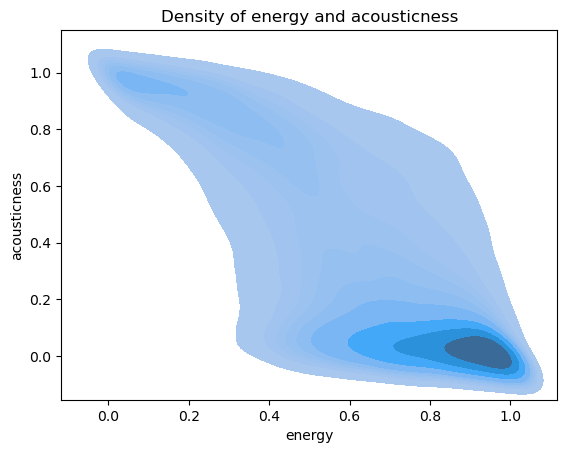

In [240]:
# 5 density plots comparing features with energy
# way to see how well songs can be correlated

features = ["valence","loudness","tempo","loudness", "acousticness"]

for f in features:
    sns.kdeplot(data=df,x="energy",y=f,fill=True,levels=10)
    plt.title(f"Density of energy and {f}")
    plt.show()

## Step 3: Collaborative Filtering
- We will now use NMF to find users' similarities with repeated songs

In [242]:
def train_test_split(df, test_size=0.2):
    """
    Function to randomly shuffle our data frame by each user  
    Split it into training and testing dataframes

    ARGS:
        df - user dataframe
        test_size - default 0.2. 20% of each user into testing 

    RETURNS: split dataframes
        train_df: the training dataframe (1-test_size) %
        test_df: testing dataframe  (test_size) %
    """

    train_rows = []
    test_rows = []

    # splitting based on user so that there is TEST_SIZE % in testing of each user
    for user, user_df in df.groupby('user_idx'):

        # shuffle user df so that we can have random train/testing 
        user_df = user_df.sample(frac=1, random_state=42)

        n_test = max(1, int(len(user_df) * test_size))
        test = user_df.iloc[:n_test]
        train = user_df.iloc[n_test:]

        train_rows.append(train)
        test_rows.append(test)

    # make into pandas df
    train_df = pd.concat(train_rows)
    test_df = pd.concat(test_rows)

    return train_df, test_df

In [243]:
# create matrix for Nonnegative matrix factorization
# rows are user, columns are song, filled with 1 if they repeated a song and 0 otherwise


# randomly sample the data so that we can debug easily 20% of the data
sample_users = collab['user'].drop_duplicates().sample(frac=0.2, random_state=42)
practice = collab[collab['user'].isin(sample_users)].copy()


# label encode the users and songs to build the sparse matrix
user_encoder = LabelEncoder()
song_encoder = LabelEncoder()

practice['user_idx'] = user_encoder.fit_transform(practice['user'])
practice['name_idx'] = song_encoder.fit_transform(practice['name'])

train_df, test_df = train_test_split(practice)

# build the matrix
matrix = csr_matrix((train_df['repeated'], (train_df['user_idx'], train_df['name_idx'])))

# check the sizes + should match the matrix size
print("Amt of users:", len(user_encoder.classes_))
print("Amt of songs:", len(song_encoder.classes_))
print("Matrix size:", matrix.shape)

Amt of users: 2351
Amt of songs: 87513
Matrix size: (2351, 87513)


In [244]:
# Why we use NMF: 
# https://communities.sas.com/t5/SAS-Communities-Library/Non-negative-Matrix-Factorization-Part-1-Understanding-Its/ta-p/973592

# NMF model
nmf_model = NMF(n_components=20, init='nndsvd', random_state=42, max_iter=200)

# lower rank decomposed matricies
W = nmf_model.fit_transform(matrix) # user latent features
H = nmf_model.components_ # song latent features / weights

/opt/anaconda3/lib/python3.12/site-packages/sklearn/decomposition/_nmf.py:1720: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(


In [245]:
# function to print out top ten recommended songs
def recommend_user(user_idx, W, H, train_matrix, top_k=10):
    """
    Function to return K top recommended songs based on a user

    ARGS:
    user_idx: the user to recommend to
    W: user latent features
    H: song latent features
    train_matrix: the sparse matrix
    top_K: integer value of TOP K songs to return (default 10)

    RETURNS:
    top_song_indices: sorted songs by top K recommended
    """

    # predict scores based on user id
    scores = W[user_idx] @ H

    # REMOVE already seen songs
    seen_songs = train_matrix[user_idx].indices
    scores[seen_songs] = -np.inf

    # sort songs by most recommended
    top_song_indices = np.argsort(scores)[::-1][:top_k]

    return top_song_indices

In [246]:
def decode_songs(song_indices, song_encoder):
    """
    Function that decodes the label encoded songs

    ARGS:
    song_indecies: the label encoded songs
    spng_encoder: label encoding 

    RETURNS:
    the decoded songs
    """

    return song_encoder.inverse_transform(song_indices)

In [247]:
test_lookup = (test_df.groupby('user_idx')['name_idx'].apply(set).to_dict())
test_lookup

{0: {590,
  1054,
  7835,
  9116,
  9262,
  9544,
  13380,
  17263,
  18880,
  19078,
  20346,
  20816,
  22716,
  24233,
  26098,
  28036,
  28058,
  28091,
  31728,
  32078,
  32380,
  34427,
  34862,
  35714,
  36731,
  37856,
  38075,
  40793,
  41993,
  43976,
  47370,
  48531,
  49891,
  50412,
  50940,
  51475,
  51646,
  52500,
  53170,
  53643,
  56489,
  57676,
  60393,
  61496,
  61811,
  62373,
  62471,
  62593,
  64082,
  64183,
  64484,
  64635,
  66013,
  68450,
  69566,
  71242,
  72913,
  72960,
  77214,
  78010,
  80424,
  82544,
  83546,
  83598,
  84822,
  84838,
  84902,
  85583,
  86545},
 1: {164,
  984,
  1662,
  1690,
  2598,
  5104,
  5223,
  5690,
  7698,
  9262,
  11864,
  14244,
  14295,
  15209,
  16645,
  18493,
  18880,
  19660,
  20329,
  20415,
  20478,
  20724,
  20939,
  20988,
  21408,
  23336,
  23417,
  24136,
  25260,
  25261,
  26829,
  27167,
  27398,
  27460,
  27664,
  27956,
  28036,
  31282,
  32078,
  32463,
  32970,
  33716,
  33737,
  34

In [248]:
def precision_at_k(W, H, train_matrix, test_lookup, k=10):
    """
    Function to return the Precision@K which is how relevant the top K recommended songs are 

    ARGS:
    W: user latent features
    H: song latent features
    train_matrix: sparse matrix
    test_lookup: dictionary of grouped testing data to compare for relevance
    k: top K songs that we recommend

    RETURNS:
    Precision@K value
    """

    precisions = []

    for user_idx in test_lookup.keys():

        recommended = recommend_user(user_idx,W,H,matrix,top_k=k)
        relevant = test_lookup[user_idx]
        hits = len(set(recommended) & relevant)
        precisions.append(hits / k)

    return np.mean(precisions)

In [249]:
precision = precision_at_k(W,H,matrix,test_lookup,k=10)
print("Precision@10:", precision)

Precision@10: 0.36329221607826456


In [250]:
usercount = len(user_encoder.classes_)
# list 10 random users
users = random.sample(range(usercount), 10)

for user in users:
    recommended_indices = recommend_user(user,W,H, matrix,top_k=10)
    recommended_songs = decode_songs(recommended_indices,song_encoder)
    print(f"User #{user}")
    print(recommended_songs)
    print()

User #564
['再會中港路' '我的路' '回來我身邊' '嫁給我吧' 'Love Me Like You Do' '心內的話' 'See You Again'
 'Lost Stars' '癡情玫瑰花' '吼搭啦']

User #1416
['再會中港路' '9453' '下輩子' '你不愛我' '歪國人' '演員' 'Sing Me to Sleep' 'Sugar'
 '你，好不好？ (How Have You Been?)' '不為誰而作的歌 (Twilight)']

User #1739
['心內的話' 'BANG BANG BANG' '棟未條' 'FLY OUT' 'IF YOU' 'LOSER' 'TT'
 'Stay With Me' 'CHEER UP' '每一個玩音樂的人 (feat. 玖壹壹、陳零九) (Music Is Our Dream)']

User #375
['演員' '告白氣球' '帥到分手' '謝謝妳愛我 (Thanks For Your Love)' '不該'
 '後來的我們 (Here| After| Us)' '你，好不好？ (How Have You Been?)' '讓我留在你身邊'
 '小幸運 (A little happiness)' '不為誰而作的歌 (Twilight)']

User #1146
['不該' '小幸運 (A little happiness)' '不為誰而作的歌 (Twilight)'
 '孤獨是會上癮的 (Addicted To Loneliness)' 'FLY OUT' '光年之外' '當你'
 '愛在身邊 (Unbreakable Love)' '很愛過一個人 (Loved Someone)' '微笑帶過 (Passing Smile)']

User #548
['Lost Stars' '演員' '忘記擁抱' '分手需要練習的'
 '我不知道愛是什麼 (Wo Bu Zhi Dao Ai Shi Shen Mo)' '愛著愛著就永遠' '爸爸媽媽 (Mama & Papa)'
 '今晚你想念的人是不是我' '失落沙洲' '旅行的意義']

User #2017
['你，好不好？ (How Have You Been?)' 'Alone' '孤獨是會上癮的 (Addict